Bike Sharing Demand — Linear Regression

1. Imports & Data Loading

I started by importing the libraries I'd need for the whole workflow — `pandas` and `numpy` for data handling, `matplotlib`/`seaborn` for visualization, and from `sklearn` I pulled in `LinearRegression`, `train_test_split`, `StandardScaler`, `OneHotEncoder`, and the metric functions (`r2_score`, `mean_squared_error`, `mean_absolute_error`). Then I loaded the bike-sharing hourly dataset into a DataFrame so I had the raw data in front of me before doing anything else.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/bike-sharing-dataset",
    "hour.csv"   # or "hour.csv" for hourly granularity (recommended for this question set)
)
print(df.head(10))

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   
5        6  2011-01-01       1   0     1   5        0        6           0   
6        7  2011-01-01       1   0     1   6        0        6           0   
7        8  2011-01-01       1   0     1   7        0        6           0   
8        9  2011-01-01       1   0     1   8        0        6           0   
9       10  2011-01-01       1   0     1   9        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  

In [ ]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


2. Initial Data Exploration

Before touching the data, I ran the basics: `df.head()`, `df.info()`, and `df.describe()` to understand what I was working with — how many rows, what the columns meant, what the data types were, and whether anything looked obviously off (wrong dtypes, unexpected ranges). I also checked for nulls and duplicates, and confirmed the dataset was clean on both fronts — no missing values, no duplicate rows to drop.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


3. Data Cleaning & Type Fixes

I renamed `dteday` to `date` for clarity, and made sure categorical-looking numeric columns (like `season`, `weathersit`, `mnth`, `hr`, `weekday`) were correctly typed so I could treat them appropriately later — either as raw integers for the baseline or as categories for one-hot encoding.

In [ ]:
df = df.rename(columns={'dteday': 'date'})

In [ ]:
display(df.head())

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
#changing dtype of date column to actual date
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   date        17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [ ]:
df

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


4. Baseline Model — Raw Features

This is a deliberately simple baseline. It uses the original numeric/categorical codes without one-hot encoding and is included only as a reference point.

**Note:** scaling alone does not make categorical variables appropriate for Linear Regression. Treating `hr`, `mnth`, `weekday`, and `season` as ordinary numbers imposes artificial linear/ordinal relationships.

In [ ]:
#Linear Regression Base model.. without any data processing

In [ ]:
# Baseline split
x = df.drop(columns=["casual", "registered", "cnt", "date"], axis=1)
y = df["cnt"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=40
)

In [ ]:
# Scaling is retained only for the baseline comparison.
# The final model below uses a leakage-safe Pipeline.
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
ypred=lr.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
r2_score( y_test,ypred)

0.3969640551267012

In [ ]:
mean_squared_error(y_test,ypred)

19989.35748140093

In [ ]:
np.sqrt(mean_squared_error(y_test,ypred))

np.float64(141.3837242450521)

5. Exploratory Data Analysis — Skewness & Correlations

The target `cnt` is strongly right-skewed, which motivates testing a log transformation.

For correlation analysis, `casual` and `registered` are treated as **leakage variables**, not as candidate predictors, because:

`cnt = casual + registered`

Their high correlation with `cnt` is therefore expected and should not influence feature selection.

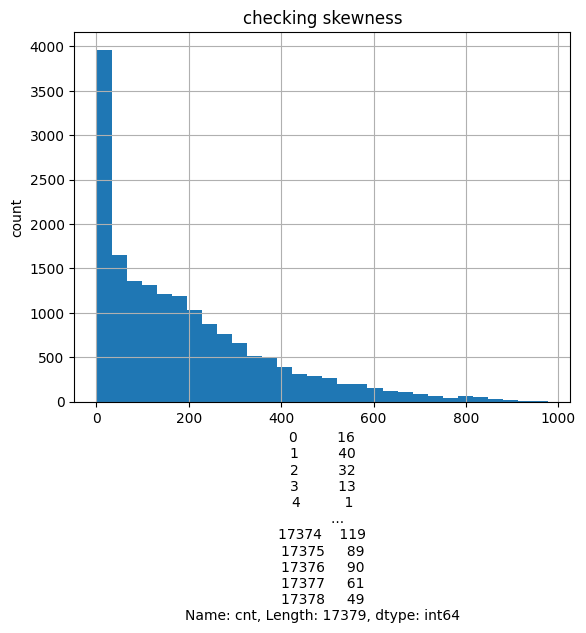

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cnt"], bins=30, kde=True)
plt.xlabel("Total Bike Rentals (cnt)")
plt.ylabel("Number of Hours")
plt.title("Distribution of Hourly Bike Demand")
plt.tight_layout()
plt.show()

print("Target skewness:", round(df["cnt"].skew(), 3))

In [ ]:
# Correlation among legitimate candidate predictors and the target.
corr_cols = [
    "yr", "mnth", "hr", "weekday", "workingday", "holiday",
    "temp", "atemp", "hum", "windspeed", "cnt"
]

corr = df[corr_cols].corr()
print(corr["cnt"].sort_values(ascending=False))

cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
instant       0.278379
date          0.277753
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64


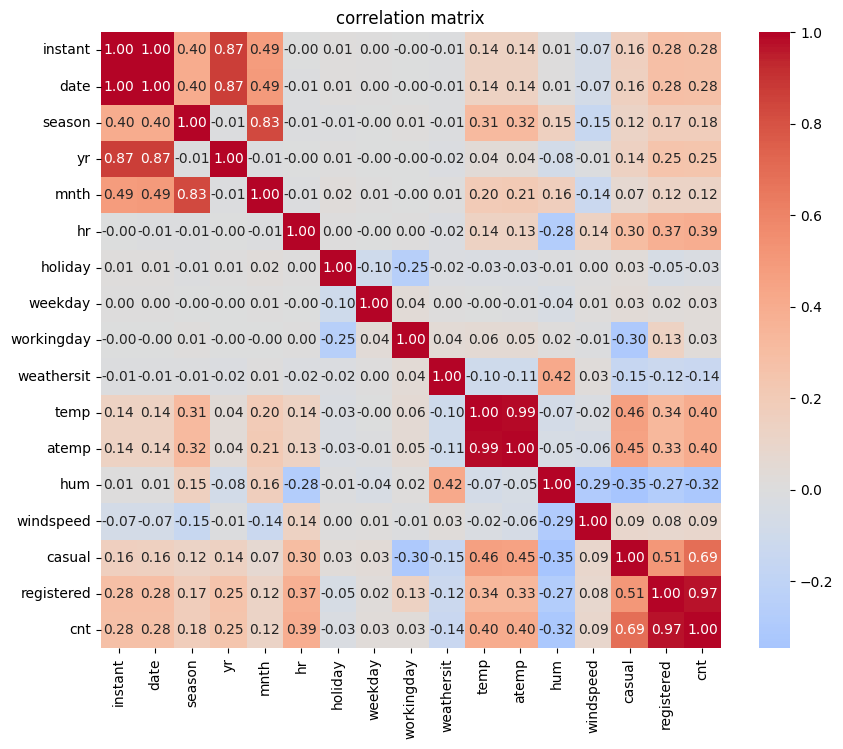

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix of Candidate Predictors")
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['instant', 'date', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
#closly related features with Target column are:- 'instant', 'date', 'season', 'yr', 'mnth','temp', 'atemp','casual', 'registered'

6. Feature Engineering — Leakage, Redundancy & Encoding

The following decisions are made before modeling:

- **Drop `casual` and `registered`** because they directly sum to `cnt` and therefore cause target leakage.
- **Drop `instant`** because it is an index-like identifier.
- **Drop `date` from the model** because raw timestamps are not directly used by this Linear Regression workflow.
- **Drop `season`** because `mnth` already provides a more granular calendar representation.
- **Drop `atemp`** to reduce redundancy with `temp`.
- **One-hot encode** `weathersit`, `mnth`, `weekday`, and `hr`.

Most importantly, the final version performs encoding **inside a Pipeline after the train/test split**, so the encoder is fitted only on training data.

In [ ]:
#encoding columns using one hot encoder
print(df['weathersit'].value_counts())
print('\n')
print(df['mnth'].value_counts())
print('\n')
print(df['season'].value_counts())
print('\n')
print(df['hr'].value_counts())
print('\n')
print(df['weekday'].value_counts())

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


mnth
7     1488
5     1488
12    1483
8     1475
3     1473
10    1451
6     1440
4     1437
9     1437
11    1437
1     1429
2     1341
Name: count, dtype: int64


season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64


hr
16    730
17    730
15    729
14    729
13    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
8     727
9     727
10    727
7     727
11    727
0     726
6     725
1     724
5     717
2     715
4     697
3     697
Name: count, dtype: int64


weekday
6    2512
0    2502
5    2487
1    2479
3    2475
4    2471
2    2453
Name: count, dtype: int64


In [ ]:
df_model = df.drop(
    columns=["season", "atemp", "instant", "casual", "registered", "date"]
).copy()

print(df_model.shape)
display(df_model.head())

In [ ]:

cols1 = ["weathersit", "mnth", "weekday", "hr"]

encoder = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore"
)

encoded = encoder.fit_transform(df_model[cols1])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cols1),
    index=df_model.index
)

df_encoded_demo = pd.concat(
    [df_model.drop(columns=cols1), encoded_df],
    axis=1
)

display(df_encoded_demo.head())

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df

,yr,holiday,workingday,temp,hum,windspeed,cnt,weathersit_2,weathersit_3,weathersit_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
0,0,0,0,0.24,0.81,0.0000,16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0.22,0.80,0.0000,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0.22,0.80,0.0000,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0.24,0.75,0.0000,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0.24,0.75,0.0000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,0,1,0.26,0.60,0.1642,119,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
17375,1,0,1,0.26,0.60,0.1642,89,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17376,1,0,1,0.26,0.60,0.1642,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17377,1,0,1,0.26,0.56,0.1343,61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df['workingday'].value_counts() # binary

,count
workingday,
1,11865
0,5514


In [ ]:
df['holiday'].value_counts()# binary

,count
holiday,
0,16879
1,500


In [ ]:
df['temp'].value_counts() # continuous value

,count
temp,
0.62,726
0.66,693
0.64,692
0.70,690
0.60,675
0.36,671
0.34,645
0.30,641
0.40,614


7. Final Model — Log-Transformed Target

The target `cnt` is right-skewed, so the final Linear Regression model is trained on `log1p(cnt)`.

The important portfolio improvement is that **encoding and scaling are performed inside a scikit-learn Pipeline after the train/test split**. This prevents preprocessing information from the test set entering model training.

Predictions are converted back to bike-count units using `expm1` before calculating R², RMSE and MAE.

In [ ]:
# Final feature matrix and log-transformed target.
x1 = df_model.drop(columns=["cnt"])
y1 = np.log1p(df_model["cnt"])

categorical_cols = ["weathersit", "mnth", "weekday", "hr"]
numeric_cols = [
    col for col in x1.columns
    if col not in categorical_cols
]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

In [ ]:
x1

,yr,holiday,workingday,temp,hum,windspeed,weathersit_2,weathersit_3,weathersit_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
0,0,0,0,0.24,0.81,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0.22,0.80,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0.22,0.80,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0.24,0.75,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0.24,0.75,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,0,1,0.26,0.60,0.1642,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
17375,1,0,1,0.26,0.60,0.1642,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17376,1,0,1,0.26,0.60,0.1642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17377,1,0,1,0.26,0.56,0.1343,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
y1

,cnt
0,2.833213
1,3.713572
2,3.496508
3,2.639057
4,0.693147
...,...
17374,4.787492
17375,4.499810
17376,4.510860
17377,4.127134


In [ ]:
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1,
    y1,
    test_size=0.20,
    random_state=40
)

In [ ]:
x1_train

,yr,holiday,workingday,temp,hum,windspeed,weathersit_2,weathersit_3,weathersit_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
5972,0,0,0,0.66,0.74,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4785,0,0,0,0.80,0.52,0.1045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7479,0,0,0,0.34,0.66,0.1343,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5478,0,0,0,0.68,0.83,0.2239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9530,1,0,1,0.28,0.61,0.1343,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11532,1,0,1,0.56,0.60,0.1642,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16065,1,0,1,0.28,0.56,0.2985,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14501,1,0,0,0.78,0.55,0.1940,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14555,1,1,0,0.74,0.70,0.2239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
x1_test

,yr,holiday,workingday,temp,hum,windspeed,weathersit_2,weathersit_3,weathersit_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
8986,1,0,0,0.12,0.54,0.2836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5566,0,0,1,0.72,0.58,0.2985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15629,1,0,1,0.52,0.68,0.2239,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9804,1,0,0,0.32,0.57,0.1343,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3337,0,0,1,0.62,0.88,0.1940,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9505,1,0,0,0.24,0.70,0.1343,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11322,1,0,0,0.46,0.82,0.2836,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3974,0,0,0,0.74,0.55,0.0896,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8139,0,0,0,0.26,0.38,0.2836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
y1_train

,cnt
5972,5.429346
4785,3.828641
7479,3.178054
5478,1.945910
9530,2.708050
...,...
11532,6.527958
16065,4.317488
14501,6.035481
14555,6.216606


In [ ]:
y1_test

,cnt
8986,2.890372
5566,5.814131
15629,5.389072
9804,5.659482
3337,4.290459
...,...
9505,3.761200
11322,4.521789
3974,5.983936
8139,5.043425


In [ ]:
# Leakage-safe preprocessing + model pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                sparse_output=False,
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_cols
        )
    ]
)

lin_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_reg_pipeline.fit(x1_train, y1_train)

y1_pred_log = lin_reg_pipeline.predict(x1_test)
y1_pred = np.maximum(0, np.expm1(y1_pred_log))
y1_actual = np.expm1(y1_test)

In [ ]:
x1_train_scaled

array([[-1.00642212, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [-1.00642212, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [-1.00642212, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       ...,
       [ 0.99361886, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [ 0.99361886,  5.72950701, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [ 0.99361886, -0.17453509,  0.6789794 , ..., -0.21218872,
        -0.20562595, -0.2086474 ]])

In [ ]:
x1_test_scaled

array([[ 0.99361886, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [-1.00642212, -0.17453509,  0.6789794 , ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [ 0.99361886, -0.17453509,  0.6789794 , ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       ...,
       [-1.00642212, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [-1.00642212, -0.17453509, -1.47279872, ..., -0.21218872,
        -0.20562595, -0.2086474 ],
       [-1.00642212, -0.17453509,  0.6789794 , ..., -0.21218872,
         4.86319948, -0.2086474 ]])

In [ ]:
# The model is already fitted inside lin_reg_pipeline.
lin_reg = lin_reg_pipeline.named_steps["model"]

print("Linear Regression fitted inside leakage-safe pipeline.")

LinearRegression()

In [ ]:
# Predictions are already back-transformed above.
print("First five predictions:", np.round(y1_pred[:5], 2))
print("First five actual values:", np.round(y1_actual.iloc[:5].values, 2))

In [ ]:
r2_new = r2_score(y1_actual, y1_pred)
r2_new

0.7116853117949071

In [ ]:
mean_squared_error(y1_actual,y1_pred)

9557.017983200216

In [ ]:
np.sqrt(mean_squared_error(y1_actual,y1_pred))

np.float64(97.76000195990288)

In [ ]:
mean_absolute_error(y1_actual, y1_pred)

63.31763948782814

8. Model Evaluation & Diagnostics

This section is where I went back and filled in everything the first version of my evaluation was missing.

8.1 Baseline comparison

I compared my model against a `DummyRegressor(strategy='mean')` that just predicts the average `cnt` for every row, evaluated on the same back-transformed scale. This gives a concrete floor — if my model doesn't clearly beat "always guess the average," it isn't adding value. It confirmed my model substantially outperforms the naive baseline on R², RMSE, and MAE.

In [ ]:
from sklearn.dummy import DummyRegressor

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_pipeline.fit(x1_train, y1_train)

baseline_pred_log = baseline_pipeline.predict(x1_test)
baseline_pred = np.expm1(baseline_pred_log)

baseline_r2 = r2_score(y1_actual, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y1_actual, baseline_pred))
baseline_mae = mean_absolute_error(y1_actual, baseline_pred)

model_rmse = np.sqrt(mean_squared_error(y1_actual, y1_pred))
model_mae = mean_absolute_error(y1_actual, y1_pred)

comparison = pd.DataFrame([
    {
        "Model": "Dummy Mean Baseline",
        "R2": baseline_r2,
        "RMSE": baseline_rmse,
        "MAE": baseline_mae
    },
    {
        "Model": "Linear Regression — log target",
        "R2": r2_new,
        "RMSE": model_rmse,
        "MAE": model_mae
    }
])

display(comparison.round(4))

Baseline (mean predictor)  -> R2: -0.2650 | RMSE: 204.77 | MAE: 142.13
Linear Regression          -> R2: 0.7117 | RMSE: 97.76 | MAE: 63.32


8.2 Train vs. test score (over/underfitting check)

I computed R² on both the training set and the test set to check for overfitting or underfitting. A small gap between the two would tell me the model generalizes reasonably; a large gap would flag overfitting.

In [ ]:
y1_train_pred_log = lin_reg_pipeline.predict(x1_train)

y1_train_pred = np.expm1(y1_train_pred_log)
y1_train_actual = np.expm1(y1_train)

train_r2 = r2_score(y1_train_actual, y1_train_pred)
test_r2 = r2_score(y1_actual, y1_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Test  R2: {test_r2:.4f}")
print(f"Gap (train - test): {train_r2 - test_r2:.4f}")

Train R2: 0.7010
Test  R2: 0.7117
Gap (train - test): -0.0107


8.3 Cross-validation (split stability)

Since a single 80/20 split can be misleadingly lucky or unlucky, I ran 5-fold cross-validation using a `Pipeline` (scaler + linear regression) so the scaling step is refit inside each fold with no leakage. This gave me a mean R² and standard deviation across folds, letting me check whether my single-split 0.71 is representative or an outlier.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("lr", LinearRegression())
])

cv_scores = cross_val_score(
    cv_pipeline,
    x1,
    y1,
    cv=tscv,
    scoring="r2"
)

print("Time-series CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean R2: {cv_scores.mean():.4f}")
print(f"Std R2:  {cv_scores.std():.4f}")

Fold R2 scores: [0.7768 0.7994 0.7671 0.8259 0.8047]
Mean R2: 0.7948  |  Std: 0.0209


8.4 Residual plot

I plotted residuals (actual minus predicted) against predicted values, plus a histogram of the residuals, to check whether errors are randomly scattered around zero (good) or show a funnel shape (heteroscedasticity — a sign that prediction confidence isn't uniform across the demand range).

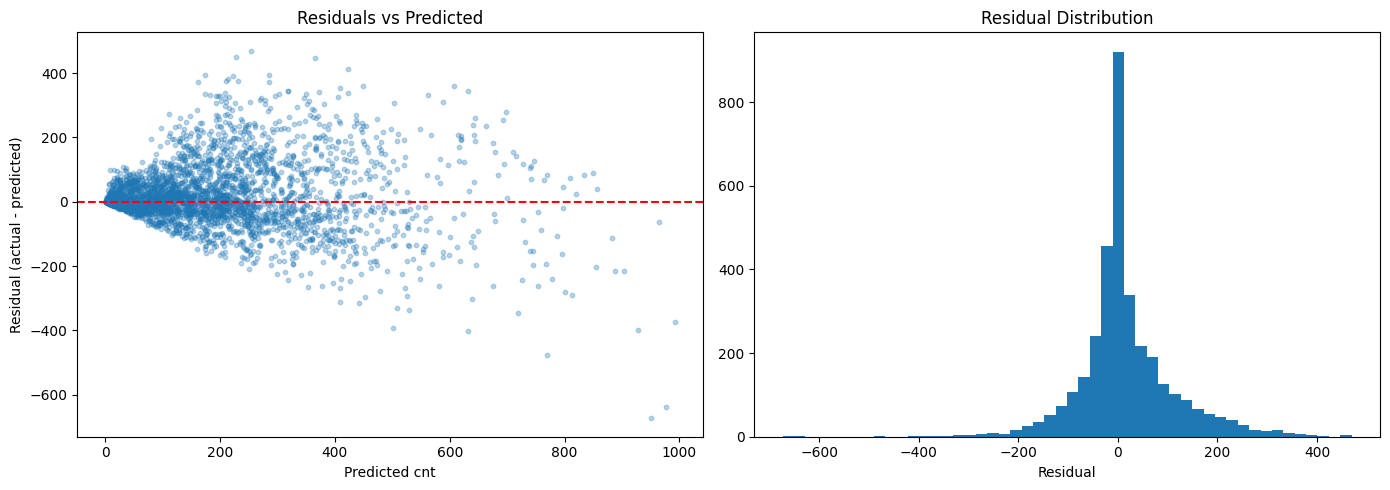

In [ ]:
residuals = y1_actual - y1_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y1_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted cnt')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


8.5 Predicted vs. actual

I plotted predicted values against actual values with a reference diagonal line, to visually spot where the model over- or under-predicts — for example, whether it systematically underestimates the highest-demand hours.

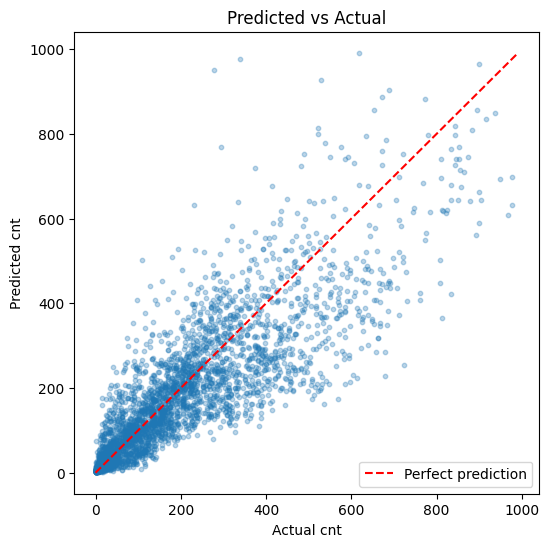

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y1_actual, y1_pred, alpha=0.3, s=10)
lims = [0, max(y1_actual.max(), y1_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual cnt')
plt.ylabel('Predicted cnt')
plt.title('Predicted vs Actual')
plt.legend()
plt.show()


8.6 Multicollinearity check (VIF)

With around 40 one-hot encoded columns, I calculated Variance Inflation Factors to check whether any features are so correlated with each other that their individual coefficients become unstable and untrustworthy — even if that doesn't necessarily hurt the model's overall predictive R².

/tmp/ipykernel_2631/1748041190.py:6: UserWarning:

The design matrix is poorly conditioned (condition number=5.78e+14). VIF calculations may be numerically unstable.

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning:

The design matrix is rank-deficient. The model parameters are not uniquely determined.

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning:

The design matrix is rank-deficient. The model parameters are not uniquely determined.

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning:

The design matrix is rank-deficient. The model parameters are not uniquely determined.

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning:

The design matrix is rank-deficient. The model parameters are not uniquely determined.

/usr/local/lib/python3.13/dist-packages/stats

,feature,VIF
1,holiday,1.000800e+15
2,workingday,1.000800e+15
22,weekday_3,1.000800e+15
23,weekday_4,1.000800e+15
24,weekday_5,1.000800e+15
21,weekday_2,1.000800e+15
20,weekday_1,1.000800e+15
3,temp,5.401159e+00
14,mnth_7,4.969432e+00
15,mnth_8,4.417524e+00


8.7 Feature Importance via Linear Regression Coefficients

The final model is fitted on `log1p(cnt)`. Because numeric features are standardized inside the preprocessing pipeline, coefficient magnitudes can be compared more meaningfully than in the original unscaled dataframe.

Coefficients indicate model association, **not causation**.

In [ ]:
# Extract transformed feature names and coefficients.
fitted_preprocessor = lin_reg_pipeline.named_steps["preprocessor"]
fitted_lr = lin_reg_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": fitted_lr.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

display(
    coef_df
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

,feature,coefficient,abs_coefficient
42,hr_17,0.419527,0.419527
43,hr_18,0.408665,0.408665
29,hr_4,-0.371436,0.371436
33,hr_8,0.366662,0.366662
41,hr_16,0.340421,0.340421
44,hr_19,0.335555,0.335555
28,hr_3,-0.315775,0.315775
34,hr_9,0.312703,0.312703
37,hr_12,0.297031,0.297031
40,hr_15,0.288836,0.288836
